#    Introduction
### In this notebook, I will explore uncicorn companies to help investment firms make their next profitable investment

 
## Step 1: Imports


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

In [3]:
# Load data from the csv file into a DataFrame and save in a variable

df = pd.read_csv("Downloads/Unicorn_Companies.csv")

## Step 2: Data exploration                                 

In [4]:
# Display the first 10 rows of the data                                                
df.head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,1/8/18,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,5/2/19,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,12/30/14,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,12/20/17,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2/5/19,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


### Column insights
- Select investors - investors with largest shares

- Date Joined - when the comapny became an unicorn

- Funding - money invested by the investors

- Valuation - value of the company

- year Founded - year in which a company was established

In [5]:
# How large the dataset is

df.size

10740

In [6]:
# Shape of the dataset

df.shape

(1074, 10)

In [7]:
# Get information

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country/Region    1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


Company              0
Valuation            0
Date Joined          0
Industry             0
City                16
Country/Region       0
Continent            0
Year Founded         0
Funding              0
Select Investors     1
dtype: int64

####  Data type insights
- Year Founded - int64 (Can be converted to panda's date type)
- Date Joined - object (Needs to be converted to panda's date type)

#####  Column counts
- The City column has 16 missing values
- Select Investors column has a null entry


#  Step 3:descriptive Statistical tests

In [8]:
df.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


##### Statistics insight
- Earliest unicorn company in the dataset was founded in 1919 (Over 100 years ago)
- Latest unicorn company in the dataset was founded in 2021 (5 years ago)

In [17]:
# Step 1. Use pd.to_datetime() to convert Date Joined column to datetime 
# Step 2. Update the column with the converted values

df["Date Joined"] = pd.to_datetime(df["Date Joined"], errors="coerce")

In [10]:
# Use .info() to confirm that the update actually took place

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country/Region    1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


In [11]:
#  Use .dt.year to extract year component from Date Joined column
df["Year Joined"] = df["Date Joined"].dt.year

In [12]:
# Use .head() to confirm that the new column did get added

df.head(1)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017


# Step 4: Results and evaluation
let's sample some companies

In [13]:
# Take a sample of 50 companies 

df_sample = df.sample(n = 50, random_state =42)


In [14]:
df_sample

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined
542,Aiven,$2B,2021-10-18,Internet software & services,Helsinki,Finland,Europe,2016,$210M,"Institutional Venture Partners, Atomico, Early...",2021
370,Jusfoun Big Data,$2B,2018-07-09,Data management & analytics,Beijing,China,Asia,2010,$137M,"Boxin Capital, DT Capital Partners, IDG Capital",2018
307,Innovaccer,$3B,2021-02-19,Health,San Francisco,United States,North America,2014,$379M,"M12, WestBridge Capital, Lightspeed Venture Pa...",2021
493,Algolia,$2B,2021-07-28,Internet software & services,San Francisco,United States,North America,2012,$334M,"Accel, Alven Capital, Storm Ventures",2021
350,SouChe Holdings,$3B,2017-11-01,E-commerce & direct-to-consumer,Hangzhou,China,Asia,2012,$1B,"Morningside Ventures, Warburg Pincus, CreditEa...",2017
237,Webflow,$4B,2021-01-13,Internet software & services,San Francisco,United States,North America,2012,$335M,"Accel, Silversmith Capital Partners, capitalG",2021
475,Gousto,$2B,2020-11-03,"Supply chain, logistics, & delivery",London,United Kingdom,Europe,2012,$311M,"MMC Ventures, BGF Ventures, Unilever Ventures",2020
578,Misfits Market,$2B,2021-04-21,E-commerce & direct-to-consumer,Pennsauken,United States,North America,2018,$527M,"Accel, D1 Capita Partners, Greenoaks Capital M...",2021
462,Hibob,$2B,2021-10-12,Internet software & services,Tel Aviv,Israel,Asia,2015,$274M,"Bessemer Venture Partners, Eight Roads Venture...",2021
978,News Break,$1B,2021-01-07,Internet software & services,Mountain View,United States,North America,2015,$151M,"IDG Capital, Francisco Partners, ZhenFund",2021


### 01) Visualize the time it took companies to reach unicorn status ? 


In [15]:


# Prepare data for plotting

# Create new `years_till_unicorn` column
df_sample["Years_still_unicorn"] = df_sample["Year Joined"]-df_sample["Year Founded"]


# Group the data by `Industry`. For each industry, get the max value in the `years_till_unicorn` column.
grouped = (df_sample[["Industry", "Years_still_unicorn"]]
           .groupby("Industry")
           .max()
           .sort_values(by= "Years_still_unicorn")
          )
        
grouped


,Years_still_unicorn
Industry,
Consumer & retail,1
Auto & transportation,2
Artificial intelligence,5
Data management & analytics,8
Mobile & telecommunications,9
"Supply chain, logistics, & delivery",12
Internet software & services,13
Other,15
E-commerce & direct-to-consumer,18


##### Key insights
- Consumer and transporation companies became the unicorn within 1-2 years after launching



Let's plot the bar chart for visual representation

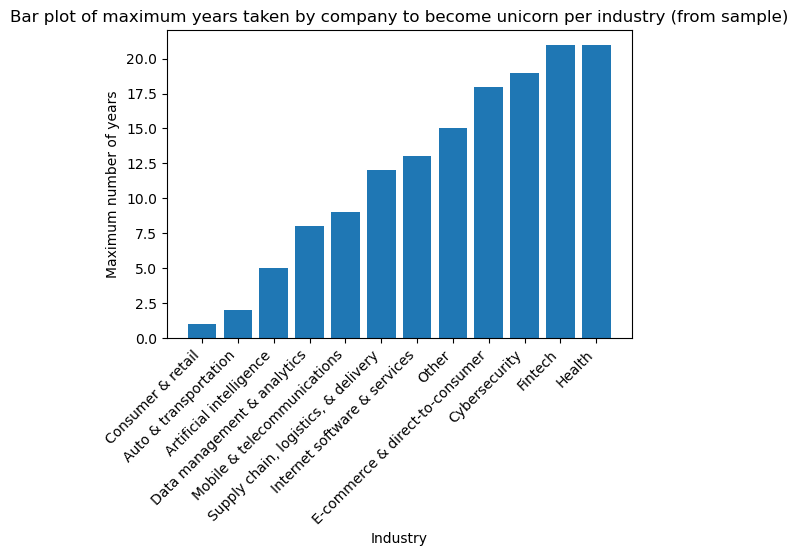

In [19]:
# Create bar plot

# maintain size of figur
plt.figure(figsize=(6,4))


plt.bar(grouped.index , grouped["Years_still_unicorn"] )

plt.title("Bar plot of maximum years taken by company to become unicorn per industry (from sample)")
plt.xlabel ("Industry")
plt.ylabel ("Maximum number of years")
# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text 
plt.xticks(rotation=45, horizontalalignment= "right")

plt.show()



#### Bar chart insights
- Fintech and Health companies took the longest to become an unicorn

---


###                                02)   Visualize the maximum unicorn company valuation per industry ?

In [20]:
# Create a column representing company valuation as numeric data

# Create new column
df_sample["valuation billions"] = df_sample["Valuation"]

# Remove the '$' from each value
df_sample["valuation billions"] = df_sample["valuation billions"].str.replace("$", "")

# Remove the 'B' from each value
df_sample["valuation billions"] = df_sample["valuation billions"].str.replace("B", "")

# Convert column to type int
df_sample["valuation billions"] = df_sample["valuation billions"].astype("int")

# Display the plot
df_sample.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Years_still_unicorn,valuation billions
542,Aiven,$2B,2021-10-18,Internet software & services,Helsinki,Finland,Europe,2016,$210M,"Institutional Venture Partners, Atomico, Early...",2021,5,2
370,Jusfoun Big Data,$2B,2018-07-09,Data management & analytics,Beijing,China,Asia,2010,$137M,"Boxin Capital, DT Capital Partners, IDG Capital",2018,8,2
307,Innovaccer,$3B,2021-02-19,Health,San Francisco,United States,North America,2014,$379M,"M12, WestBridge Capital, Lightspeed Venture Pa...",2021,7,3
493,Algolia,$2B,2021-07-28,Internet software & services,San Francisco,United States,North America,2012,$334M,"Accel, Alven Capital, Storm Ventures",2021,9,2
350,SouChe Holdings,$3B,2017-11-01,E-commerce & direct-to-consumer,Hangzhou,China,Asia,2012,$1B,"Morningside Ventures, Warburg Pincus, CreditEa...",2017,5,3


In [21]:
# Prepare data for modeling

grouped = (df_sample[["Industry", "valuation billions"]]
           .groupby("Industry")
           .max()
           .sort_values(by = "valuation billions")
          )
grouped
           



,valuation billions
Industry,
Auto & transportation,1
Consumer & retail,1
Other,2
"Supply chain, logistics, & delivery",2
Cybersecurity,3
Health,3
Data management & analytics,4
E-commerce & direct-to-consumer,4
Internet software & services,5


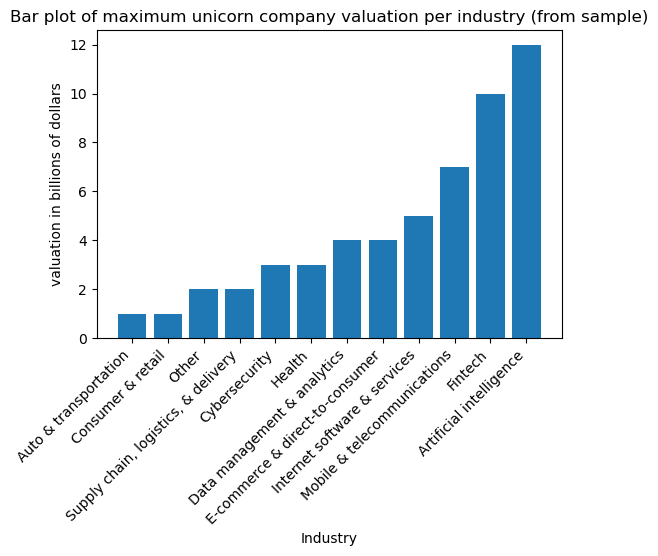

In [22]:
# Create bar plot
# with Industry column as the categories of the bars
# and new valuation column as the heights of the bars



plt.figure(figsize=(6,4))
plt.bar  (grouped. index , grouped ["valuation billions"])


# Set title
plt.title ("Bar plot of maximum unicorn company valuation per industry (from sample)")

# Set x-axis label
plt.xlabel  ("Industry")

# Set y-axis label
plt.ylabel  ("valuation in billions of dollars")


# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text
plt.xticks  (rotation = 45, horizontalalignment = "right")

# Display the plot
plt.show()


#### Bar plot insights
- AI company has the highest valuation
- Retail and transporation companies have the lowest valuation even after reaching the unicorn status earliest

# Part 2
### 03) sort the dataset to get insights on latest companies ?

In [23]:
df.sort_values(by= "Year Founded", ascending = False).head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined
782,Phantom,$1B,2022-01-31,Fintech,San Francisco,United States,North America,2021,$118M,"Paradigm, Andreessen Horowitz, Jump Capital",2022
714,Yidian Zixun,$1B,2017-10-17,Mobile & telecommunications,Beijing,China,Asia,2021,$151M,"Phoenix New Media, Tianjin Haihe Industry Fund",2017
822,GlobalBees,$1B,2021-12-28,E-commerce & direct-to-consumer,New Delhi,India,Asia,2021,$185M,"Chiratae Ventures, SoftBank Group, Trifecta Ca...",2021
554,ClickHouse,$2B,2021-10-28,Data management & analytics,Portola Valley,United States,North America,2021,$300M,"Lightspeed Venture Partners, Almaz Capital Par...",2021
952,LayerZero Labs,$1B,2022-03-30,Internet software & services,New York,United States,North America,2021,$143M,"Andreessen Horowitz, FTX Ventures, Tiger Globa...",2022
314,Flink Food,$3B,2021-12-01,E-commerce & direct-to-consumer,Berlin,Germany,Europe,2021,$1B,"Mubadala Capital, Bond, Prosus Ventures",2021
864,Aptos,$1B,2022-03-15,Internet software & services,Palo Alto,United States,North America,2021,$200M,"Andreessen Horowitz, Coinbase Ventures, Tiger ...",2022
238,Yuga Labs,$4B,2022-03-22,Fintech,Miami,United States,North America,2021,$450M,"Andreessen Horowitz, Thrive Capital, Sound Ven...",2022
775,Jokr,$1B,2021-12-02,E-commerce & direct-to-consumer,New York,United States,North America,2021,$430M,"GGV Capital, Tiger Global Management, Greycroft",2021
967,Mensa Brands,$1B,2021-11-16,Other,Bengaluru,India,Asia,2021,$218M,"Accel, Falcon Edge Capital, Norwest Venture Pa...",2021


## Insights
- The latest companies (in the dataset) were founed in the year 2021
- Most of the latest companies are from North America
- Andreessen Horowitz seems to be the most active investor in these companies (in US)
- All the companies are from tech industry

---
### 04) Determine the number of companies founded each year ?



In [24]:
# Display each unique year that occurs in the dataset
# along with the number of companies that were founded in each unique year.

df["Year Founded"].value_counts().sort_values(ascending = False)

Year Founded
2015    155
2016    110
2014    109
2012     95
2013     87
2011     82
2017     74
2018     61
2019     45
2010     40
2009     34
2008     27
2020     25
2007     24
2006     15
2005     14
2000     11
2021     11
2001      9
1999      8
2004      8
2003      8
1998      5
2002      4
1994      2
1995      2
1992      1
1993      1
1990      1
1984      1
1996      1
1979      1
1991      1
1919      1
1997      1
Name: count, dtype: int64

## Insights
- Most comapanies were found in the year 2015 and 2016

Histogram will represent frequency distribution of how frequently a variable occurred (year to company count in this case)

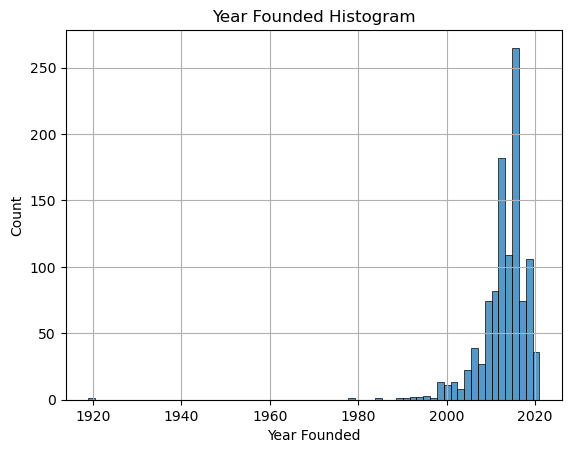

In [25]:
import seaborn as sns

sns.histplot(x='Year Founded', data=df)
plt.title('Year Founded Histogram')
plt.grid()


The histogram is left skewed because most of the companies were founded after 2005
 

--- 
####  Create a `Month Joined` column

In [26]:
# Obtain the names of the months when companies gained unicorn status.
# Use the result to create a `Month Joined` column.


df["Month joined"] = df["Date Joined"].dt.month_name()
df.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,April
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,December
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018,July
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014,January
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011,December


We can usse the Month Joined column for further analysis as per the requirements

### 05) count Unicorn companies  by month ?

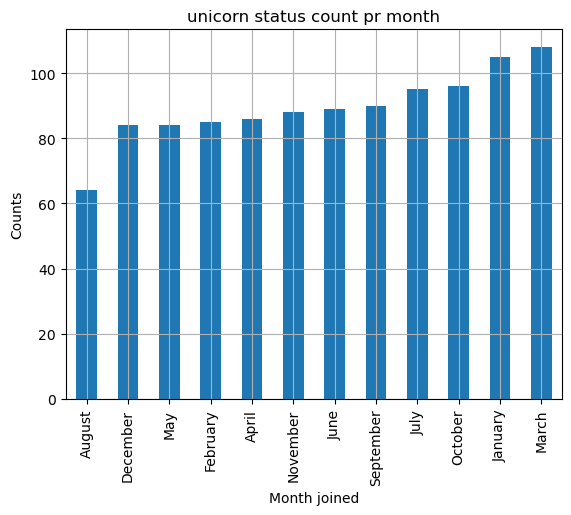

In [27]:
df ["Month joined"] .value_counts().sort_values().plot(kind = 'bar')
plt.ylabel('Counts')
plt.title('unicorn status count pr month')
plt.grid()

---
# Gain more insight on a specific year (For the year 2021)

## Observe trends over time:
 
 ### 06) In which quarter of 2021 did the companies become unicorns the most ?

In [28]:
# Step 1: Filter the dataset to include only companies that became unicorns in 2021
# Step 2: Display first two rows to check the filtered data

df_2021 = df[df['Year Joined'] == 2021]
df_2021.head(2)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined
12,FTX,$32B,2021-07-20,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,July
16,J&T Express,$20B,2021-04-07,"Supply chain, logistics, & delivery",Jakarta,Indonesia,Asia,2015,$5B,"Hillhouse Capital Management, Boyu Capital, Se...",2021,April


In [29]:
# Step 3: Check the number of rows and columns in the 2021 dataset
df_2021.shape

(520, 12)

In [30]:
# Step 4: Sort companies based on valuation and view the top 10 companies
df_2021.sort_values(by='Valuation').head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined
51,Alchemy,$10B,2021-10-28,Fintech,San Francisco,United States,North America,2017,$564M,"DFJ Growth Fund, Coatue Management, Addition",2021,October
53,Digital Currency Group,$10B,2021-11-01,Fintech,New York,United States,North America,2015,$1B,"Ribbit Capital, capitalG, Softbank Group",2021,November
39,ZongMu Technology,$11B,2021-06-03,Auto & transportation,Shanghai,China,Asia,2013,$376M,"LTW Capital, Legend Capital, Qualcomm Ventures",2021,June
42,Weilong Foods,$11B,2021-05-08,Consumer & retail,Luohe,China,Asia,1999,$558M,"Tencent Holdings, Hillhouse Capital Management...",2021,May
44,Bolt,$11B,2021-10-08,Fintech,San Francisco,United States,North America,2014,$1B,"Activant Capital, Tribe Capital, General Atlantic",2021,October
34,Getir,$12B,2021-03-26,E-commerce & direct-to-consumer,Istanbul,Turkey,Europe,2015,$2B,"Tiger Global Management, Sequoia Capital, Revo...",2021,March
37,GoodLeap,$12B,2021-10-13,Internet software & services,Roseville,United States,North America,2003,$800M,"New Enterprise Associates, BDT Capital Partner...",2021,October
27,OpenSea,$13B,2021-07-20,E-commerce & direct-to-consumer,New York,United States,North America,2017,$427M,"Andreessen Horowitz, Thirty Five Ventures, Sou...",2021,July
24,Blockchain.com,$14B,2021-02-17,Fintech,London,United Kingdom,Europe,2011,$490M,"Lightspeed Venture Partners, Google Ventures, ...",2021,February
1072,Zopa,$1B,2021-10-19,Fintech,London,United Kingdom,Europe,2005,$792M,"IAG Capital Partners, Augmentum Fintech, North...",2021,October


In [50]:
# Step 5: Extract the quarter from the date when companies became unicorns
# This helps analyze trends over time in 2021
df_2021.loc[:,'Quarter'] = df_2021['Date Joined'].dt.to_period('Q').dt.strftime("Q%q")

In [32]:
# Step 6: Display the updated dataset with quarter information
df_2021.head(2)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined,Quarter
12,FTX,$32B,2021-07-20,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,July,Q3
16,J&T Express,$20B,2021-04-07,"Supply chain, logistics, & delivery",Jakarta,Indonesia,Asia,2015,$5B,"Hillhouse Capital Management, Boyu Capital, Se...",2021,April,Q2


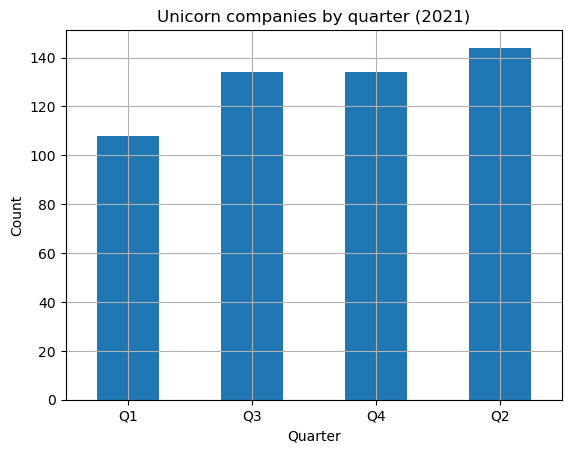

In [33]:
# Step 7: Count the number of unicorn companies in each quarter
# and visualize the trend using a bar chart
df_2021['Quarter'].value_counts().sort_values().plot(kind='bar')

# Step 8: Add chart title and labels for better understanding
plt.title('Unicorn companies by quarter (2021)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid()


### Insights
- Q2 (2021) has the highest number of unicorn companies
---



## Compare trends over time :
### 08)  compare the valuation of companies by quarters for the years 2021 and 2020 ?

In [34]:
 # see the pervious dataset (2021)
df_2021.head(2)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined,Quarter
12,FTX,$32B,2021-07-20,Fintech,NaN,Bahamas,North America,2018,$2B,"Sequoia Capital, Thoma Bravo, Softbank",2021,July,Q3
16,J&T Express,$20B,2021-04-07,"Supply chain, logistics, & delivery",Jakarta,Indonesia,Asia,2015,$5B,"Hillhouse Capital Management, Boyu Capital, Se...",2021,April,Q2


In [35]:
# Step 1. Filter by the additional year  to create a subset that consists of companies that joined in that year 

df_2020 = df[df["Year Joined"] == 2020]
df_2020.head(2)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined
22,Genki Forest,$15B,2020-03-01,Consumer & retail,Beijing,China,Asia,2016,$721M,"Sequoia Capital China, Longfor Capitalm, Gaoro...",2020,March
23,goPuff,$15B,2020-10-08,E-commerce & direct-to-consumer,Philadelphia,United States,North America,2013,$3B,"Accel, Softbank Group, Anthos Capital",2020,October


In [36]:
# Step 2. Concatenate that new subset (2020) with the subset that you defined previously (2021).
df_2020_2021 = pd.concat([df_2020, df_2021.drop(columns=['Quarter'])])

In [37]:
# step 3. check the shape of combined new dataset
df_2020_2021.shape[0] == df_2020.shape[0] + df_2021.shape[0]

True

In [38]:
# step 4.  Add `Quarter Joined` column to `companies_2021`.
df_2020_2021["Quarter Joined"] = df_2020_2021["Date Joined"].dt.to_period('Q').dt.strftime('%Y-Q%q')

In [39]:
# step 5.  Convert the `Valuation` column to numeric by removing `$` and `B` and casting each value to data type `float`.
df_2020_2021["Valuation"] =  df_2020_2021["Valuation"].str.strip("$B").astype(float)

In [40]:
# step 6.   Step 6: Group the data by quarter joined and calculate the mean valuation of companies for each quarte 
grouped_df_2020_2021 = df_2020_2021[['Quarter Joined', 'Valuation']].groupby(by='Quarter Joined')['Valuation'].mean().reset_index()

In [41]:
grouped_df_2020_2021.head(8)

,Quarter Joined,Valuation
0,2020-Q1,3.444444
1,2020-Q2,3.777778
2,2020-Q3,3.896552
3,2020-Q4,3.697674
4,2021-Q1,2.750000
5,2021-Q2,2.340278
6,2021-Q3,2.291045
7,2021-Q4,1.850746


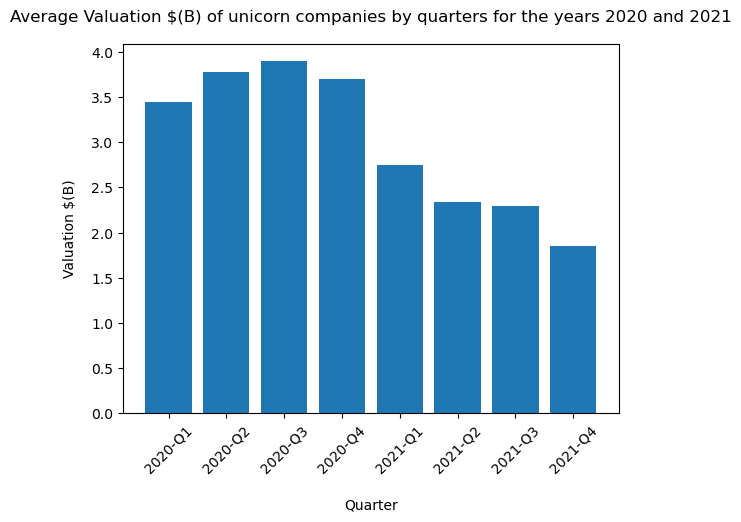

In [42]:
# step 7.  show by Bar chart

plt.bar(x=grouped_df_2020_2021['Quarter Joined'], height=grouped_df_2020_2021['Valuation'])
plt.xticks(rotation=45)
plt.xlabel('Quarter',labelpad=16)
plt.ylabel('Valuation $(B)', labelpad=10)
plt.title('Average Valuation $(B) of unicorn companies by quarters for the years 2020 and 2021', pad=16)
plt.show()


### Insights
- It is clear that the average valuation of the unicorn companies in the year 2020 was higher in every quarter



---
##  Time-to-unicorn visualization :
### 09)  Visualize the time it took companies to become unicorns

In [43]:
df['Years To Unicorn'] = df['Year Joined'] - df['Year Founded']


In [44]:
df.head(2)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Month joined,Years To Unicorn
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017,April,5
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012,December,10


In [45]:
# Define a list that contains months in chronological order.

month_order =["January", "February", "March","April", "May", "June", "July","August", "September", "October", 
    "November", "December"]

print(month_order)

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


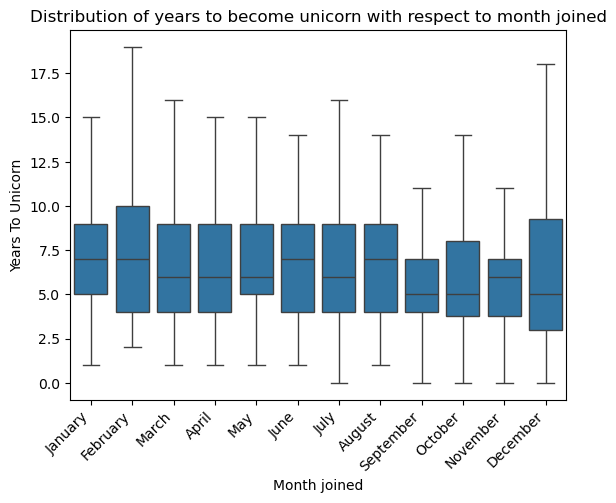

In [46]:
# Create the box plot to visualize the distribution of how long it took companies to become unicorns, with respect to the month they joined.
# Make sure the x-axis goes in chronological order by month, using the list you defined previously.
# Plot the data from the `companies` DataFrame.


sns.boxplot(x= df["Month joined"],
            y= df["Years To Unicorn"],
            order= month_order,
            showfliers= False)

# Set the title of the plot.
plt.title('Distribution of years to become unicorn with respect to month joined')
# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text. 
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()


### Insights
- Median values for Sepetember and October are the least

- --

### 10) Time Founded vs Time to Become Unicorn Bar Plot ?

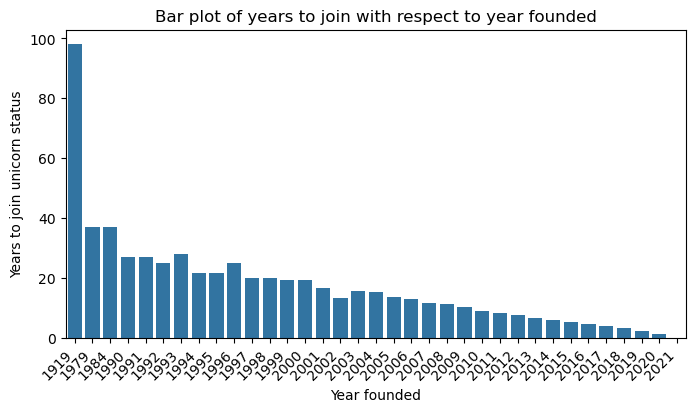

In [47]:
plt.figure(figsize=(8,4))
sns.barplot(x=df["Year Founded"], y=df["Years To Unicorn"], errorbar=None)
plt.title("Bar plot of years to join with respect to year founded")
plt.xlabel("Year founded")
plt.ylabel("Years to join unicorn status")
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

### Insights
- With the passage of time, on average, companies are taking less time to reach unicorn status. \ Note: This is a bias that is common in time data—because companies founded in later years have been around for less time. Therefore, there is less time to collect data on such companies compared to companies founded in earlier years).
 ---

### 11) Average Valuation Over the Quarters (2020 - 2021) ?

In [48]:
grouped_df_2020_2021['Quarter Number'] = grouped_df_2020_2021['Quarter Joined'].str[-2:]
grouped_df_2020_2021['Year Joined'] = grouped_df_2020_2021['Quarter Joined'].str[:4]
grouped_df_2020_2021.rename(columns={"Valuation": "Average Valuation"}, inplace=True)
grouped_df_2020_2021.head()

,Quarter Joined,Average Valuation,Quarter Number,Year Joined
0,2020-Q1,3.444444,Q1,2020
1,2020-Q2,3.777778,Q2,2020
2,2020-Q3,3.896552,Q3,2020
3,2020-Q4,3.697674,Q4,2020
4,2021-Q1,2.750000,Q1,2021


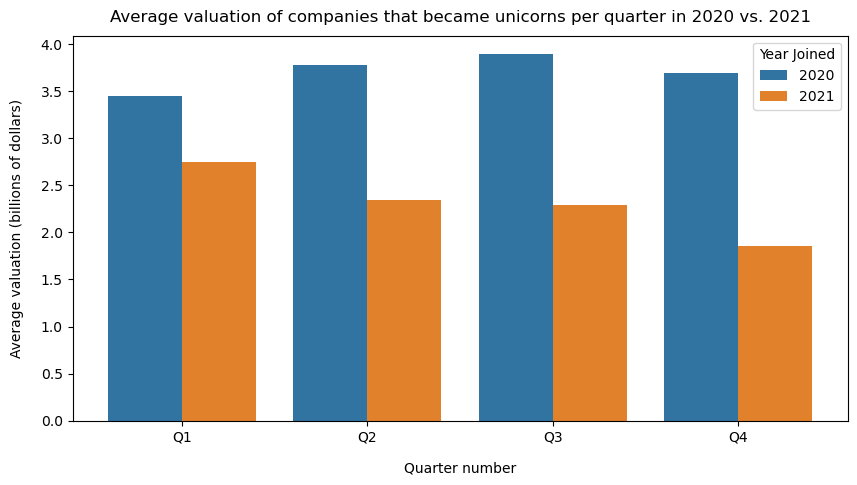

In [49]:
plt.figure(figsize = (10, 5))

sns.barplot(x=grouped_df_2020_2021['Quarter Number'],
            y=grouped_df_2020_2021['Average Valuation'],
            hue=grouped_df_2020_2021['Year Joined'])

plt.plot()

plt.xlabel("Quarter number", labelpad=12)
plt.ylabel("Average valuation (billions of dollars)", labelpad=12)

plt.title("Average valuation of companies that became unicorns per quarter in 2020 vs. 2021", pad=10)

plt.show()

### Insights
- In each quarter, the average valuation of each company that became unicorn was higher in 2020 than in 2021
- In 2020, Q3 had the highest average valuation. There was an uptrend in average valuation from Q1 to Q3
- In 2021, Q1 had the highest average valuation. The average valuation was in a downtrend from Q1 to Q4
- --

## Key Findings

- The dataset contains 1,074 unicorn companies.
- 2015 had the highest number of companies founded.
- Many unicorn companies founded in 2021 were based in the United States.
- Fintech, E-commerce & Direct-to-Consumer, and Internet Software & Services were among the leading industries for unicorn companies founded in 2021.
- Companies that achieved unicorn status in September and October generally took less time to become unicorns.
- The average valuation of companies that joined in 2021 was highest in the first quarter of the year.
- The average valuation of companies that joined in 2020 was highest in the third quarter of the year.
- --